In [1]:
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

In [2]:
using Plots                          # Plotting
using CSV, DataFrames, JLD2          # Data handling
using LinearAlgebra, StatsBase       # Linear algebra, statistics
using Random, Statistics             # Random number generation, basic statistics
using LaTeXStrings                   # LaTeX support for plots
using Revise                          # Live code reloading

using StaticArrays, LazySets          # Efficient arrays, set operations
using Interpolations, LinearInterpolations  # Interpolation utilities
using SpatiotemporalGPs               # Gaussian processes
using DifferentialEquations, ForwardDiff # Differential equations, automatic differentiation


In [3]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")

┌ Warning: Replacing docs for Main.Variograms.hp_fit :: Tuple{Any} in module
│ Main.Variograms
└ @ Base.Docs docs\Docs.jl:243


Main.ConvexBoundAvoidance

# Load Lake Wind Data

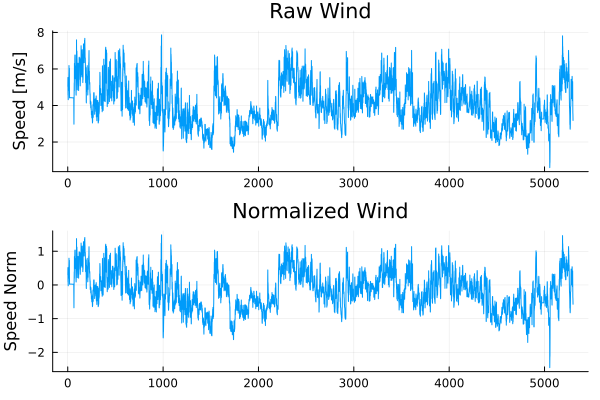

In [4]:
# Pull in wind data from csv
wind_data = CSV.read("2024-11-15_ergodic_data.csv", DataFrame)
raw_wind = wind_data.raw_wind
normal_wind = wind_data.normal_val

# Remove the initial zeroed values
clean_idx = findfirst(!iszero, raw_wind)
raw_wind = raw_wind[clean_idx:end]
normal_wind = normal_wind[clean_idx:end]
p1 = plot(raw_wind, label=false, title="Raw Wind", ylabel="Speed [m/s]")
p2 = plot(normal_wind, label=false, title="Normalized Wind", ylabel="Speed Norm")
plot(p1, p2, layout=(2,1))

In [5]:
# Create temporal data and vectors
println("Wind length: ", length(normal_wind))

T_begin = 9.0; # hours
T_end = 12.0; # hours

println("T_Begin: ", T_begin)
println("T_end: ", T_end)

t_vec = LinRange(T_begin, T_end, length(normal_wind))
dt_hrs = step(t_vec);
dt_min = dt_hrs * 60;
dt_sec = dt_min * 60;
println("Time Step in Seconds: ", dt_sec)

ts_hrs = Vector(t_vec);
ts_min = T_begin*60:dt_min:T_end*60;

Wind length: 5299
T_Begin: 9.0
T_end: 12.0
Time Step in Seconds: 2.0385050962627407


In [6]:
# setup the spatial and temporal kernels
σt = 2.0   # m/s
σs = 1.0   # m/s
lt = 0.25*60.0  # minutes
ls = 0.75   # km

kt = Matern(1/2, σt, lt)
ks = Matern(1/2, σs, ls)

SpatiotemporalGPs.STGPKF.Matern12{Float64}(1.0, 1.3333333333333333)

In [7]:
# Create spatial domain
# determine the spatial step size
dx = 0.05 # km

# create the spatial domain
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);

┌ Info: Saved animation to
└ C:\Users\kavin\AppData\Local\Temp\jl_TGfgReTotI.gif


Plots.AnimatedGif("C:\\Users\\kavin\\AppData\\Local\\Temp\\jl_TGfgReTotI.gif")
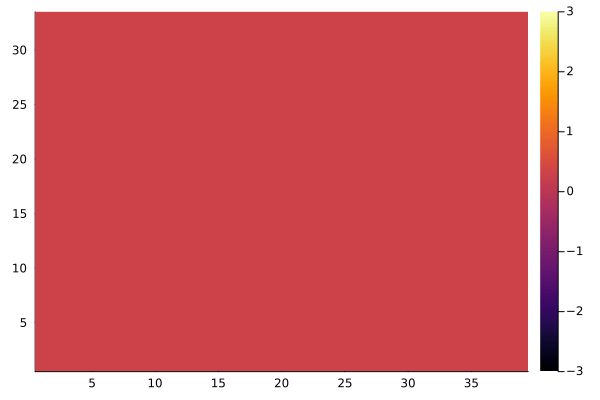

In [8]:
# Generate synthetic wind as a vector of matrices based upon the real wind data
synthetic_data = STGPKF.generate_spatiotemporal_process(xs, ys, dt_min, (T_end-T_begin)*60, ks, kt);
for idx in 1:size(synthetic_data.data)[end]
    synthetic_data.data[:,:,idx] .= normal_wind[idx]
end
@gif for idx in 1:100:size(synthetic_data.data)[end]
    heatmap(synthetic_data.data[:,:,idx], clim=(-3, 3))
end

# Controller Setup

In [9]:
# Create STGPKF Problem
problem = STGPKFProblem(grid_pts, ks, kt, dt_min)
kern = ks
ngp_grid_x = xs
ngp_grid_y = ys
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

# ASV Start Location
x0s = [@SVector[0.75, 1.0] for i=1:1]

1-element Vector{SVector{2, Float64}}:
 [0.75, 1.0]

In [10]:
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(xs), length(ys)
target_q_mat = ones(Nx, Ny)
target_q_mat *= 0.0

x_domain = xs
y_domain = ys

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if p ∈ JordanLakeDomain.convex_polygon.polygon
            target_q_mat[i, j] = 0.95
        end
    end
end

In [11]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(dt_sec)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [12]:
function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end


C_ = Cfun(0,0)
R_ = Rfun(0,0)

k = (C_^2 / R_)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end

Clarity_delta_new (generic function with 1 method)

In [21]:

function ergo_controller_weighted_2(t, xs, Mean, w_rated_val, convex_polygon;
    ergo_grid,
    ergo_q_map,
    traj,
    umax= 0.15, #30.0 * 60 / 1000,
    ΔT,
    kwargs...
    )
    
target_q = 0.95

# Set the rated value matrix    
Nx, Ny = length(synthetic_data.xs), length(synthetic_data.ys)
w_rated = ones(Nx, Ny)
w_rated *= w_rated_val

#   Compute the target matrix 
lambda_param = 0.25
delta = -lambda_param*((Mean - w_rated).^2)
q_target_temp = target_q*(exp.(delta)) 


# Mask the matrix such that q_target is zero outisde the domain
# x_domain = range(0, 1.4, length=Nx)
# y_domain = range(0, 6.5, length=Ny)
x_domain = synthetic_data.xs
y_domain = synthetic_data.ys

for i in 1:length(x_domain)
    for j in 1:length(y_domain)
        p = [x_domain[i], y_domain[j]]
        if (p ∈ convex_polygon.polygon) == false
            q_target_temp[i, j] = 0.0
        end
    end
end

# Get it in the right shape
q_target_itp = linear_interpolation((x_domain, y_domain), q_target_temp, extrapolation_bc=Interpolations.Line())
q_target_weighted = q_target_itp(ErgodicController.xs(ergo_grid), ErgodicController.ys(ergo_grid))     


target_spatial_dist = zeros(size(ergo_q_map))
Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))      

for i in CartesianIndices(target_spatial_dist)
    if q_target_weighted[i] > ergo_q_map[i]
#             println("here in first cond")
        target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], q_target_weighted[i])
    else
        target_spatial_dist[i] = 0.0
    end
end
    
u = [ErgodicController.controller_single_integrator_cvx_bound(ergo_grid, x, traj, target_spatial_dist, convex_polygon; umax=umax, do_boundary_correction=true) for x in xs]

#     println(u)

return u, q_target_temp

end

ergo_controllers_weighted_2 = [ergo_controller_weighted_2 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller_weighted_2)}:
 ergo_controller_weighted_2 (generic function with 1 method)

# Generate SOC Target Profile

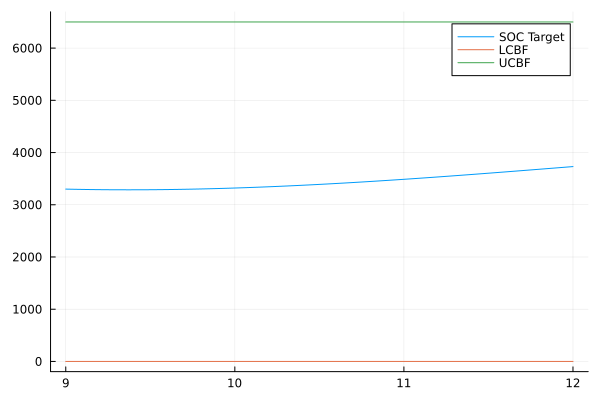

In [22]:
soc_begin = 3300
soc_end = 3500
lcbf = SoCController.compute_lcbf(ts_hrs, dt_hrs);
ucbf = SoCController.compute_ucbf(ts_hrs, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts_hrs, dt_hrs);
plot(ts_hrs, soc_target, label="SOC Target")
plot!(ts_hrs, lcbf, label="LCBF")
plot!(ts_hrs,ucbf, label="UCBF")

# Simulate

In [23]:
fuse_measurements_every_ΔT = 5.0/(60) # hours
recompute_controller_every_ΔT = 5.0 / (120.0*60) # minutes
σ_t = zeros(length(xs), length(ys));
# σ_t = zeros(66, 15);
# σ_t = zeros(256, 256);
sigma_meas = 0.0;

w_rated_val = -0.5

@time res_ergo_hp =  SimulatorST.simulate_known_param(ts_min, x0s, soc_begin, ergo_controller_weighted_2, soc_target, w_rated_val, JordanLakeDomain.convex_polygon, problem; 
    ngpkf_grid=ngpkf_grid, 
    EnvData=synthetic_data, 
    σ_meas = sigma_meas,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|█                                        |  ETA: N/A
Progress:   1%|█                                        |  ETA: 0:11:12
Progress:   1%|█                                        |  ETA: 0:11:01
Progress:   2%|█                                        |  ETA: 0:11:13
Progress:   2%|█                                        |  ETA: 0:11:09
Progress:   3%|██                                       |  ETA: 0:11:21
Progress:   3%|██                                       |  ETA: 0:11:16
Progress:   4%|██                                       |  ETA: 0:11:32
Progress:   4%|██                                       |  ETA: 0:12:40
Progress:   5%|██                                       |  ETA: 0:12:57
Progress:   5%|███                                      |  ETA: 0:12:54
Progress:   6%|███                                      |  ETA: 0:12:58
Progress:   6%|███                                      |  ETA: 0:12:50
Progress:   7%|███                                      |  ETA: 0:12

Main.SimulatorST.SimResultWeightedSpeed{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Matrix{Float64}}, Vector{Matrix{Float64}}}(540.0:0.03397508493771235:720.0, Vector{SVector{2, Float64}}[[[0.75, 1.0]], [[0.7498700386829622, 0.9999508162564354]], [[0.7500708391276497, 1.0001703077430806]], [[0.7503198596544945, 1.0005324762052348]], [[0.7506579570851519, 1.0010090461187344]], [[0.7510531497380029, 1.00162343101166]], [[0.7515015623578921, 1.0023783986227148]], [[0.7520124866513669, 1.003269369689975]], [[0.752568276475539, 1.0043073759812577]], [[0.7531712968510715, 1.0054919142518317]]  …  [[0.7307958836908844, 0.06378364467565625]], [[0.7684917570082577, 0.09463934740998681]], [[0.8201768536607098, 0.1157846750904629]], [[0.8823632847434129, 0.1290911020201494]], [[0.9246298276012802, 0.15187

812.906040 seconds (125.63 M allocations: 267.356 GiB, 18.14% gc time, 0.08% compilation time: 75% of which was recompilation)


In [24]:
jldsave("20241115_ergodic_lambdaparam_0_25.jld2"; res_ergo_hp, synthetic_data, soc_target, ts_hrs)